---
subtitle: "Lab 02 - Classification"
jupyter: python3
execute:
  enabled: true
---


<a href="https://colab.research.google.com/github/w4bo/AA2627-unibo-mldm/blob/master/slides/lab-10-modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Machine Learning

Machine Learning is the science (and art) of programming computers so they can learn from data

> **Machine Learning** is the field of study that gives computers the ability to learn without being explicitly programmed.  
> -- Arthur Samuel, 1959


# Under and overfitting

![https://xkcd.com/605/](https://github.com/w4bo/AA2627-unibo-mldm/blob/master/slides/img/modeling/slides391.png?raw=1)

# Under and overfitting

![https://xkcd.com/2048/](https://github.com/w4bo/AA2627-unibo-mldm/blob/master/slides/img/modeling/slides390.png?raw=1)

# Disclaimer

Machine learning is not just the application of some algorithms to get the best accuracy...

- You need to understand **why** a model is behaving in a certain way!
- Do not stop at the first (good) result, questioning your algorithm/pipeline is essential!
- Do not rely on external code without knowing what the code is doing
    - Remember, if you cannot explain your code the exam is not passed

In [1]:
#| echo: false
#| output: false
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

DATASET_BASE_URL = "https://raw.githubusercontent.com/w4bo/AA2627-unibo-mldm/refs/heads/main/slides/datasets/"


def find_dataset(filename):
    candidates = [
        Path("datasets") / filename,
        Path("slides") / "datasets" / filename,
        Path.cwd() / "datasets" / filename,
        Path.cwd() / "slides" / "datasets" / filename,
    ]
    for path in candidates:
        if path.exists():
            return path.resolve()
    return f"{DATASET_BASE_URL}{filename}"


# The Palmer Penguins dataset

In [2]:
penguins = pd.read_csv(find_dataset("penguins.csv"))
feature_names = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
target_categories = ["Adelie", "Chinstrap", "Gentoo"]
df = penguins.dropna(subset=feature_names + ["species"]).copy()
df["species"] = pd.Categorical(df["species"], categories=target_categories, ordered=True)
df["species_code"] = df["species"].cat.codes
target_names = target_categories
X = df[feature_names]
y = df["species_code"]
seed = 42
test_size = 0.2
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y,)
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,species_code
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,0


# Wait... what?

# Class understanding

![](https://github.com/w4bo/AA2627-unibo-mldm/blob/master/slides/img/lab-10-classification/penguin_class.png?raw=1)

# Class understanding

In [3]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

class_distribution = (
    df["species"]
    .value_counts()
    .reindex(target_names)
    .rename_axis("species")
    .to_frame("count")
)
class_distribution["proportion"] = class_distribution["count"] / class_distribution["count"].sum()
class_distribution


,count,proportion
species,,
Adelie,151,0.441520
Chinstrap,68,0.198830
Gentoo,123,0.359649


In [4]:
#| echo: false
model_performance = {}

imbalance_ratio = class_distribution["count"].min() / class_distribution["count"].max()
imbalance_threshold = 0.8
use_balanced_accuracy = imbalance_ratio < imbalance_threshold

evaluation_metric = balanced_accuracy_score if use_balanced_accuracy else accuracy_score
evaluation_scorer = "balanced_accuracy" if use_balanced_accuracy else "accuracy"
metric_label = "Balanced accuracy" if use_balanced_accuracy else "Accuracy"

# Feature understanding

![](https://github.com/w4bo/AA2627-unibo-mldm/blob/master/slides/img/lab-10-classification/feat2.png?raw=1)

# Feature understanding

![](https://github.com/w4bo/AA2627-unibo-mldm/blob/master/slides/img/lab-10-classification/feat1.png?raw=1)

- bill = becco  
- flipper = ala  
- culmen = parte superiore del becco

# Models covered in this lab

Let's see how models behave

- Decision tree
- Random forest
- k-NN
- ANN

# Decision tree

In [5]:
from sklearn.tree import DecisionTreeClassifier  # Import the model

clf = DecisionTreeClassifier(max_depth=2, random_state=seed)  # Instantiate and fit the model (on the training set)
clf.fit(X_train, y_train)  # Train the model
y_pred = clf.predict(X_test)  # Predict new values
decision_tree_test_score = evaluation_metric(y_test, y_pred)  # Evaluate the model (on the test set)
decision_tree_test_score


np.float64(0.9761904761904763)

In [6]:
#| echo: false
model_performance["Decision tree"] = {
    "model": "Decision tree",
    "configuration": "max_depth=2",
    "CV mean": np.nan,
    "CV std": np.nan,
    "test": decision_tree_test_score,
}


## Plotting the tree

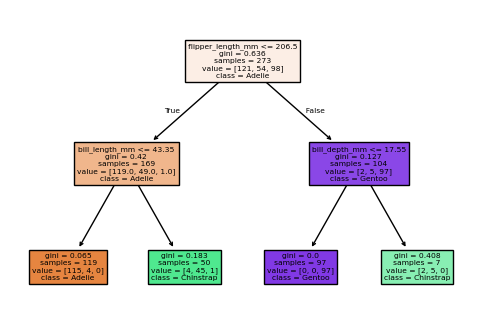

In [7]:
from sklearn.tree import plot_tree
plt.figure(figsize=(6, 4))
plot_tree(clf, feature_names=X.columns, class_names=target_names, filled=True);


## Checking feature relevance

In [8]:
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': clf.feature_importances_})  # Create a DataFrame to display feature importance
feature_importance_df = feature_importance_df.sort_values(['Importance', 'Feature'], ascending=[False, True])  # Sort the DataFrame by importance in descending order
feature_importance_df  # Display the feature importance

,Feature,Importance
2,flipper_length_mm,0.580545
0,bill_length_mm,0.351864
1,bill_depth_mm,0.067591
3,body_mass_g,0.000000


# Feature selection: checking correlations

In [9]:
X_train.corr(method='pearson', numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.234851,0.664592,0.597523
bill_depth_mm,-0.234851,1.000000,-0.589534,-0.479623
flipper_length_mm,0.664592,-0.589534,1.000000,0.866949
body_mass_g,0.597523,-0.479623,0.866949,1.000000


# Most relevant penguin measurements


In [10]:
#| echo: false

# Get the two features with the highest importance

def plot(df, model, features):
  # Create a scatter plot
  plt.figure(figsize=(3.5, 2.5))
  for species in target_names:
      species_df = df[df["species"] == species]
      plt.scatter(species_df[features[0]], species_df[features[1]], label=species, edgecolors="k")
  plt.xlabel(features[0])
  plt.ylabel(features[1])
  plt.tight_layout()
  plt.show()


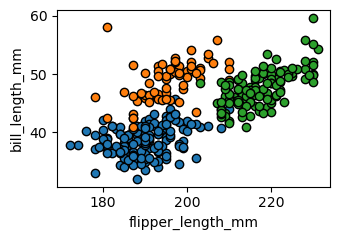

In [11]:
plot(df, clf, feature_importance_df['Feature'].iloc[:2].tolist())  # plot the 2 most important features

# Less relevant penguin measurements


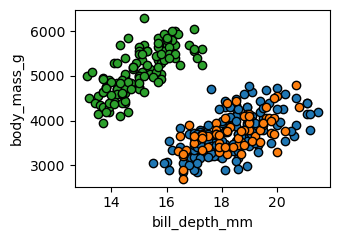

In [12]:
plot(df, clf, feature_importance_df['Feature'].iloc[2:].tolist())  # plot the 2 lest important features

# Tuning `max_depth`

What do you expect?

In [13]:
#| echo: false
#! output: false

from sklearn.preprocessing import MinMaxScaler
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

boundary_features = feature_importance_df['Feature'].iloc[:2].tolist()
X_boundary = df[boundary_features].to_numpy()
y_boundary = df["species_code"].to_numpy()

xlabel = boundary_features[0]
ylabel = boundary_features[1]
ctitle = "PALMER PENGUINS"
legend = "species"
figsize = (8, 6)
x_padding = (X_boundary[:, 0].max() - X_boundary[:, 0].min()) * 0.08
y_padding = (X_boundary[:, 1].max() - X_boundary[:, 1].min()) * 0.08
xlim = [X_boundary[:, 0].min() - x_padding, X_boundary[:, 0].max() + x_padding]
ylim = [X_boundary[:, 1].min() - y_padding, X_boundary[:, 1].max() + y_padding]
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
plt.rc("font", size=SMALL_SIZE)          # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)    # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

# Define the colormap (Tableau)
my_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
tableau_cmap = ListedColormap(my_colors)

def plot_boundary(clf, title, norm=False):
    cxlim = xlim if not norm else [-0.02, 1.02]
    cylim = ylim if not norm else [-0.02, 1.02]

    X_plot = X_boundary.copy()
    y_plot = y_boundary.copy()

    if norm:
      scaler = MinMaxScaler(feature_range=(0, 1))
      X_plot = scaler.fit_transform(X_plot)

    X_plot_train, X_plot_test, y_plot_train, y_plot_test = train_test_split(
        X_plot,
        y_plot,
        test_size=test_size,
        random_state=seed,
        stratify=y_plot,
    )
    # Train a classifier
    clf.fit(X_plot_train, y_plot_train)
    clf.train_score_ = evaluation_metric(y_plot_train, clf.predict(X_plot_train))
    clf.test_score_ = evaluation_metric(y_plot_test, clf.predict(X_plot_test))

    # Create a meshgrid for plotting decision boundaries
    x_min, x_max = [cxlim[0] - 0.5, cxlim[1] + 0.5]
    y_min, y_max = [cylim[0] - 0.5, cylim[1] + 0.5]
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    # Predict the class for each point in the meshgrid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundaries
    plt.figure(figsize=figsize)
    plt.contour(xx, yy, Z, colors="white", linewidths=1, alpha=0.8)
    plt.contourf(xx, yy, Z, cmap=tableau_cmap, alpha=0.3)

    # Plot the dataset points
    for i, class_name in enumerate(target_names):
        class_data = X_plot_train[y_plot_train == i]
        plt.scatter(class_data[:, 0], class_data[:, 1], label=class_name, marker="o", color=my_colors[i], edgecolor="k", s=70)
        class_data = X_plot_test[y_plot_test == i]
        plt.scatter(class_data[:, 0], class_data[:, 1], label=class_name + " (test)", marker="^", color=my_colors[i], edgecolor="k", s=70)

    legend_elements = [
        Line2D([0], [0], marker=None, color="w", label=legend, markerfacecolor="w", markeredgecolor="w", markersize=10),
    ]
    legend_elements.extend(
        Line2D([0], [0], marker="o", color="w", label=class_name, markerfacecolor=my_colors[i], markeredgecolor="w", markersize=10)
        for i, class_name in enumerate(target_names)
    )
    legend_elements.extend([
        Line2D([0], [0], marker=None, color="w", label="Set", markerfacecolor=None, markeredgecolor="w", markersize=10),
        Line2D([0], [0], marker="o", color="w", label="Training", markerfacecolor="white", markeredgecolor="black", markersize=10),
        Line2D([0], [0], marker="^", color="w", label="Test", markerfacecolor="white", markeredgecolor="black", markersize=10),
    ])

    plt.legend(handles=legend_elements, loc=2, ncol=2)

    plt.xlim(cxlim)
    plt.ylim(cylim)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(ctitle)

    return clf


# Decision boundaries: `max_depth=1`

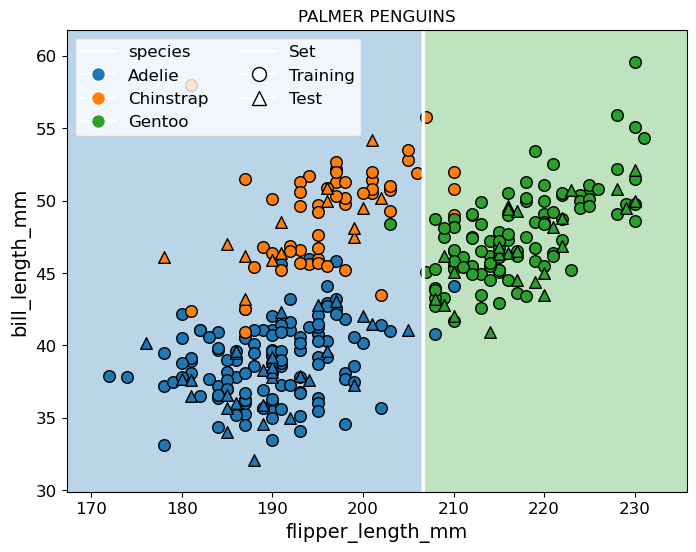

In [14]:
tree = plot_boundary(DecisionTreeClassifier(max_depth=1, random_state=seed), "decisiontree_cplot")

# Decision boundaries: `max_depth=2`

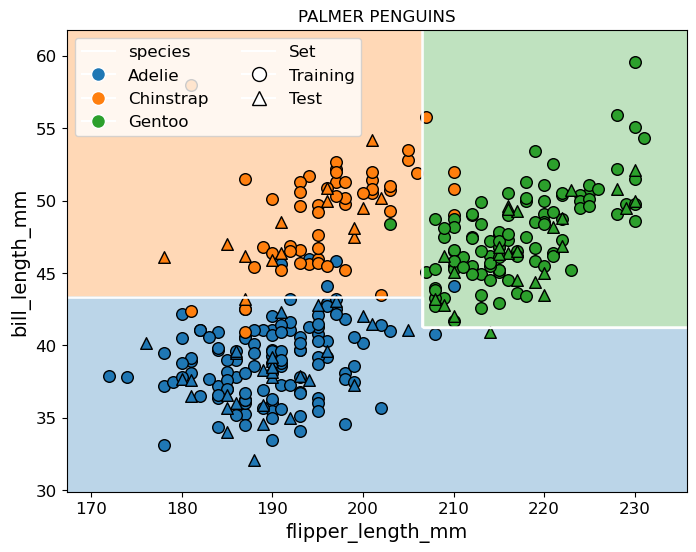

In [15]:
tree = plot_boundary(DecisionTreeClassifier(max_depth=2, random_state=seed), "decisiontree_cplot")

# Decision boundaries: `max_depth=4`

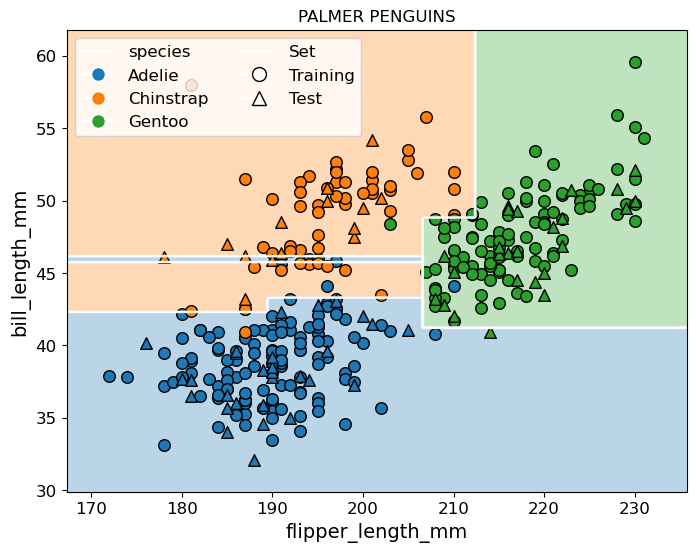

In [16]:
tree = plot_boundary(DecisionTreeClassifier(max_depth=4, random_state=seed), "decisiontree_cplot")

# Decision boundaries: `max_depth=6`

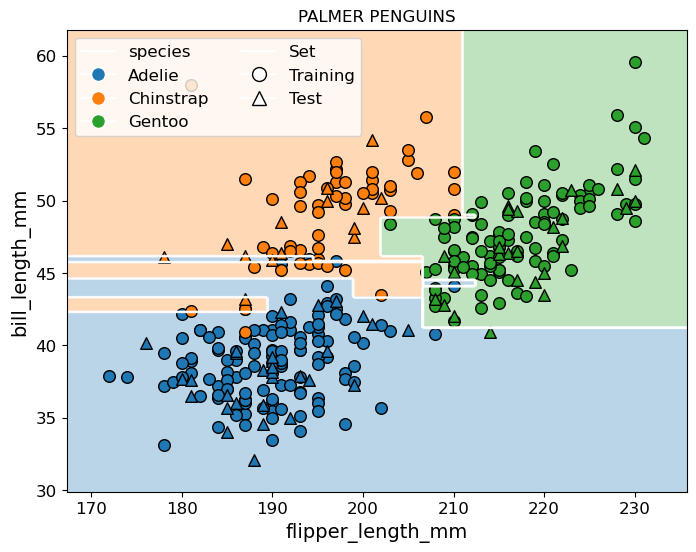

In [17]:
tree = plot_boundary(DecisionTreeClassifier(max_depth=6, random_state=seed), "decisiontree_cplot")

# Plotting training and cross-validation accuracy


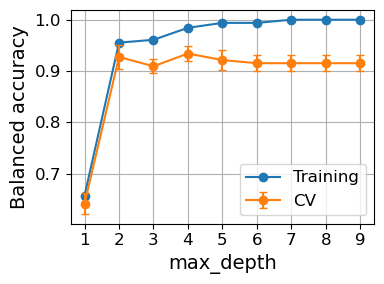

In [18]:
#| echo: false

# Prepare to store max_depth values and corresponding accuracies
max_depths = range(1, 10)
train_accuracies, cv_accuracies, cv_stds = [], [], []
for max_depth in max_depths:  # Train decision trees with increasing max_depth
    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=seed)
    clf.fit(X_train, y_train)
    train_acc = evaluation_metric(y_train, clf.predict(X_train))  # Compute accuracy for training set
    cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring=evaluation_scorer)  # Evaluate with CV on the training set
    train_accuracies.append(train_acc)
    cv_accuracies.append(cv_scores.mean())
    cv_stds.append(cv_scores.std())
# Plot accuracies
plt.figure(figsize=(4, 3))
plt.plot(max_depths, train_accuracies, label="Training", marker="o")
plt.errorbar(max_depths, cv_accuracies, yerr=cv_stds, label="CV", marker="o", capsize=3)
plt.xticks(max_depths)
plt.xlabel("max_depth")
plt.ylabel(metric_label)
plt.legend()
plt.grid(True)
plt.tight_layout()



In [19]:
#| echo: false
decision_tree_depth_index = list(max_depths).index(2)
model_performance["Decision tree"].update({
    "CV mean": cv_accuracies[decision_tree_depth_index],
    "CV std": cv_stds[decision_tree_depth_index],
})


# Hyperparameter optimization

**Hyper-parameters** are parameters that are not directly learnt within estimators.

- In scikit-learn they are passed as arguments to the constructor of the estimator classes
- How do we tune hyperparameters?


# Hyperparameter optimization

Hyper-parameters: parameters that are not directly learnt within estimators

- In scikit-learn they are passed as arguments to the constructor of the estimator classes
- Any parameter provided when constructing an estimator may be optimized

```python
estimator.get_params()
```

A search consists of:

- an estimator $(\checkmark)$
- a score function $(\checkmark)$
- a parameter space
- a method for searching or sampling candidates
- a cross-validation scheme

# Parameter space (or search space)

**Search Space**: space where each dimension represents a hyperparameter and each point represents one model configuration.

Consider the following hyperparameters of a random forest:

- `max_depth`: maximum depth of a single tree
- `n_estimators`: number of trees in the forest

Assume that the domain of the two parameters is the following:

- `max_depth` $\in [1, 10]$, `n_estimators` $\in [20, 200]$

Then, our 2D-search space is


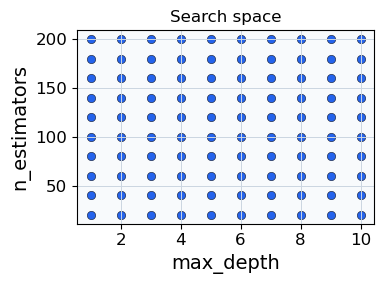

In [20]:
#| echo: false

# Creating a hypothetical 2D dataset of max_depth and n_estimators
max_depth_range = np.linspace(1, 10, 10)  # 10 values for max_depth
n_estimators_range = np.linspace(20, 200, 10)  # 10 values for n_estimators
# Generate grid points for grid search
grid_max_depth, grid_n_estimators = np.meshgrid(max_depth_range, n_estimators_range)
grid_points = np.c_[grid_max_depth.ravel(), grid_n_estimators.ravel()]
# Plotting the grid search and random search scatter plots
fig, ax1 = plt.subplots(1, 1, figsize=(4, 3))
ax1.set_facecolor("#f8fafc")
# Scatter plot for grid search
ax1.scatter(
    grid_points[:, 0],
    grid_points[:, 1],
    s=36,
    color="#2563eb",
    edgecolor="#0f172a",
    linewidth=0.4,
    label="Grid Search Points",
)
ax1.set_title("Search space")
ax1.set_xlabel("max_depth")
ax1.set_ylabel("n_estimators")
ax1.grid(True, color="#cbd5e1", linewidth=0.7)
fig.tight_layout()


# Hyper-parameter tuning

There are many search algorithms:

- *Grid search* exhaustively tries every combination of the provided hyper-parameter values in order to find the best model.
- (Pure) *Random search* samples from the entirety of the search space
    - Such optimization methods are also known as direct-search, derivative-free, or black-box methods.
    
    > If good parts of the search space occupy 5% of the volume the chances of hitting a good configuration is 5%.
    >
    > The probability of finding at least one good configuration is above 95% after trying out 60 configurations ($1 − 0.95^{60} = 0.953 > 0.95$)

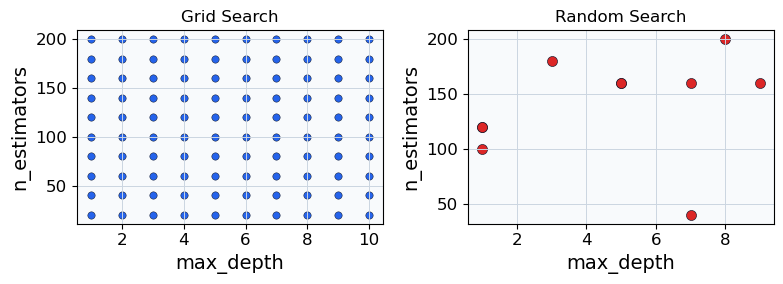

In [21]:
#| echo: false

# Creating a hypothetical 2D dataset of max_depth and n_estimators
max_depth_range = np.linspace(1, 10, 10)  # 10 values for max_depth
n_estimators_range = np.linspace(20, 200, 10)  # 10 values for n_estimators
# Generate grid points for grid search
grid_max_depth, grid_n_estimators = np.meshgrid(max_depth_range, n_estimators_range)
grid_points = np.c_[grid_max_depth.ravel(), grid_n_estimators.ravel()]
# Generate random points for random search
rng = np.random.default_rng(seed)
random_points = np.array([
    rng.choice(max_depth_range, 10),
    rng.choice(n_estimators_range, 10),
]).T
# Plotting the grid search and random search scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
for ax in (ax1, ax2):
    ax.set_facecolor("#f8fafc")
    ax.grid(True, color="#cbd5e1", linewidth=0.7)
# Scatter plot for grid search
ax1.scatter(
    grid_points[:, 0],
    grid_points[:, 1],
    s=28,
    color="#2563eb",
    edgecolor="#0f172a",
    linewidth=0.35,
    label="Grid Search Points",
)
ax1.set_title("Grid Search")
ax1.set_xlabel("max_depth")
ax1.set_ylabel("n_estimators")
# Scatter plot for random search
ax2.scatter(
    random_points[:, 0],
    random_points[:, 1],
    s=52,
    color="#dc2626",
    edgecolor="#0f172a",
    linewidth=0.45,
    label="Random Search Points",
)
ax2.set_title("Random Search")
ax2.set_xlabel("max_depth")
ax2.set_ylabel("n_estimators")
fig.tight_layout()


# Cross validation

How do we test the hyperparameter configurations?

:::: {.columns}
::: {.column width=50%}

![](https://github.com/w4bo/AA2627-unibo-mldm/blob/master/slides/img/remote/sklearn-grid-search-workflow.png?raw=1)

:::
::: {.column width=50%}

![](https://github.com/w4bo/AA2627-unibo-mldm/blob/master/slides/img/remote/sklearn-grid-search-cross-validation.png?raw=1)

:::
::::

## Example of cross correlation

![](https://github.com/w4bo/AA2627-unibo-mldm/blob/master/slides/img/remote/github-asset-d3a1aff6.png?raw=1)

# Random forest

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
rf = RandomForestClassifier(random_state=seed)  # Define a Random Forest Classifier
param_dist = {  # Set up the parameter grid for random search
    'n_estimators': randint(2, 200),        # Number of trees in the forest
    'max_depth': randint(2, 20),            # Maximum depth of the tree
    'min_samples_split': randint(2, 20),    # Minimum number of samples to split a node
    'min_samples_leaf': randint(1, 20),     # Minimum number of samples in a leaf node
}
random_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=50, scoring=evaluation_scorer, cv=cv, random_state=seed, n_jobs=-1)  # Setup RandomizedSearchCV
random_search.fit(X_train, y_train)  # Fit the random search model
print("Best Parameters from Random Search:", random_search.best_params_)  # Output the best parameters
best_rf = random_search.best_estimator_
test_score = evaluation_metric(y_test, best_rf.predict(X_test))  # Evaluate the model with the selected metric on the test set
print(f"Best cross-validation {metric_label.lower()}: {random_search.best_score_:.3f}")  # Output the best score
print(f"Test set {metric_label.lower()} with best parameters: {test_score:.3f}")


Best Parameters from Random Search: {'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 124}
Best cross-validation balanced accuracy: 0.949
Test set balanced accuracy with best parameters: 1.000


# Random forest

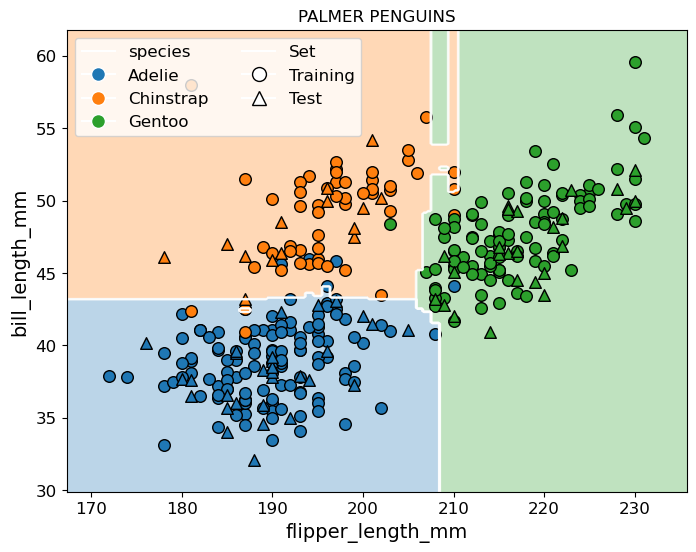

In [23]:
forest = plot_boundary(best_rf, "rf_cplot")

In [24]:
#| echo: false
rf_best_hyperparameters = ", ".join(
    f"{name}={value}" for name, value in sorted(random_search.best_params_.items())
)
model_performance["Random forest"] = {
    "model": "Random forest",
    "configuration": rf_best_hyperparameters,
    "CV mean": random_search.best_score_,
    "CV std": random_search.cv_results_["std_test_score"][random_search.best_index_],
    "test": test_score,
}


# k-Nearest Neighbors

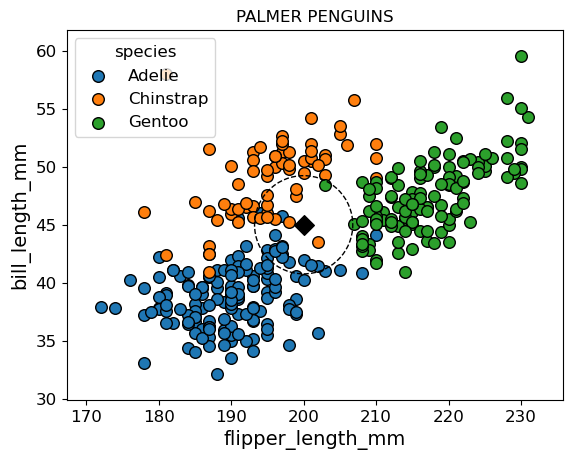

In [25]:
#| echo: false

X_plot = X_boundary
# Plot the dataset points
for i, class_name in enumerate(target_names):
    class_data = X_plot[y_boundary == i]
    plt.scatter(class_data[:, 0], class_data[:, 1], label=class_name, edgecolor="k", s=70)

plt.xlim(xlim)
plt.ylim(ylim)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title(ctitle)
plt.legend(title=legend, loc=2)

example_point = [200, 45]
plt.scatter(example_point[0], example_point[1], s=5000, facecolors="none", edgecolors="black", linestyle="--")
plt.scatter(example_point[0], example_point[1], s=100, marker="D", facecolors="black", edgecolors="black")


# Tuning `k`

What do you expect?

# Decision boundaries: `k=1` (no normalization)

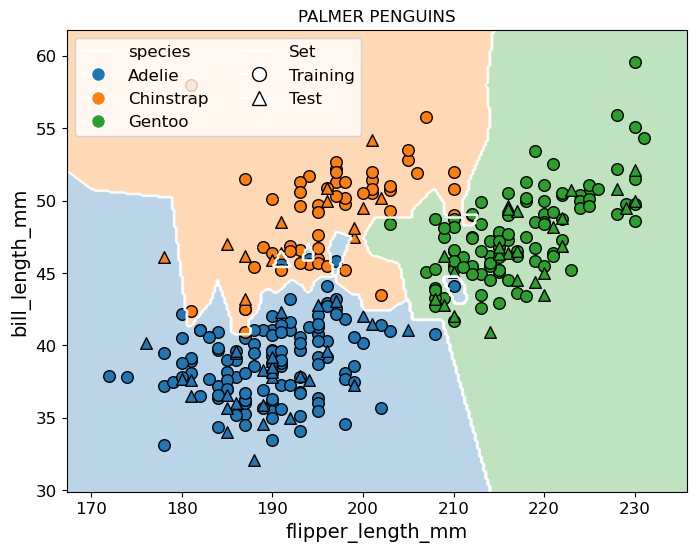

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = plot_boundary(KNeighborsClassifier(n_neighbors=1), "knn_cplot", norm=False)

# Decision boundaries: `k=1` (min-max normalization)

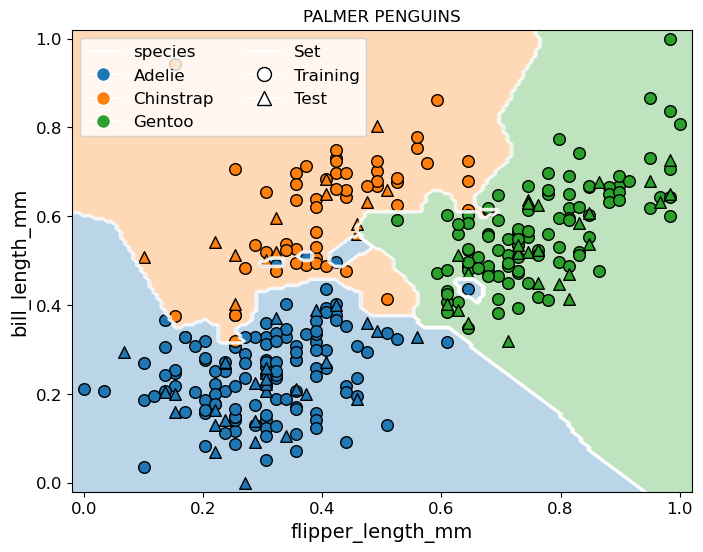

In [27]:
knn = plot_boundary(KNeighborsClassifier(n_neighbors=1), "knn_cplot", norm=True)

# Decision boundaries: `k=10` (min-max normalization)

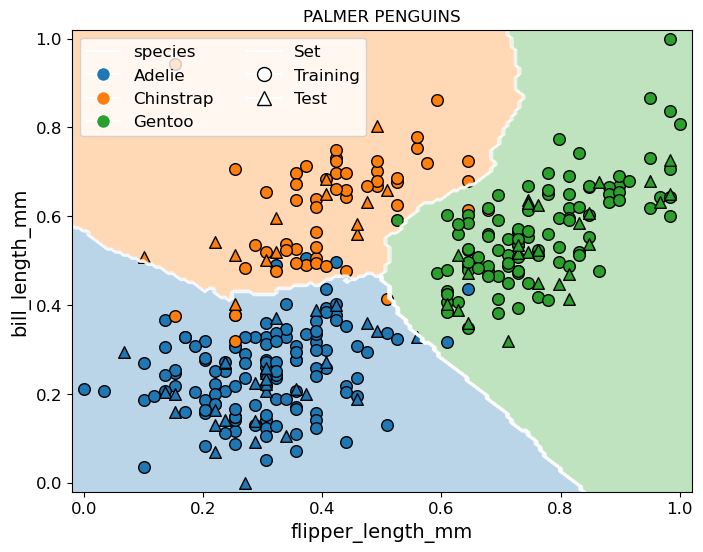

In [28]:
knn = plot_boundary(KNeighborsClassifier(n_neighbors=10), "knn_cplot", norm=True)


In [29]:
#| echo: false
model_performance.setdefault("k-NN", {
    "model": "k-NN",
    "configuration": "k=10, min-max normalization",
    "CV mean": np.nan,
    "CV std": np.nan,
}).update({"test": knn.test_score_})


# Plotting training and cross-validation accuracy


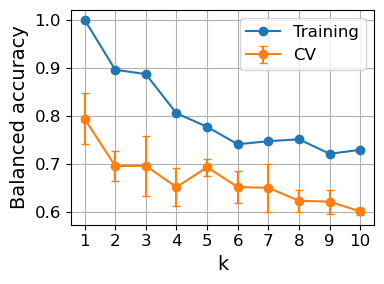

In [30]:
#| echo: false
# Prepare to store k values and corresponding accuracies
k_s = range(1, 11)
train_accuracies, cv_accuracies, cv_stds = [], [], []
for k in k_s:  # Train k-NN classifiers with increasing k
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc = evaluation_metric(y_train, knn.predict(X_train))  # Compute accuracy for training set
    cv_scores = cross_val_score(knn, X_train, y_train, cv=cv, scoring=evaluation_scorer)  # Evaluate with CV on the training set
    train_accuracies.append(train_acc)
    cv_accuracies.append(cv_scores.mean())
    cv_stds.append(cv_scores.std())
# Plot accuracies
plt.figure(figsize=(4, 3))
plt.plot(k_s, train_accuracies, label="Training", marker="o")
plt.errorbar(k_s, cv_accuracies, yerr=cv_stds, label="CV", marker="o", capsize=3)
plt.xticks(k_s)
plt.xlabel("k")
plt.ylabel(metric_label)
plt.legend()
plt.grid(True)
plt.tight_layout()



In [31]:
#| echo: false
knn_k10_index = list(k_s).index(10)
model_performance.setdefault("k-NN", {
    "model": "k-NN",
    "configuration": "k=10, min-max normalization",
    "CV mean": np.nan,
    "CV std": np.nan,
    "test": np.nan,
}).update({
    "CV mean": cv_accuracies[knn_k10_index],
    "CV std": cv_stds[knn_k10_index],
})


# Perceptron

Perceptron is binary classifier.
How can we use it in Penguins?

# One Versus All

One Versus All (OVA) strategy for multiclasses

- OVA provides a way to use binary classification for a series of yes or no predictions across multiple possible labels.
- Given a classification problem with N possible solutions, a OVA solution consists of N separate binary classifiers—one binary classifier for each possible outcome.
- During training, the model runs through a sequence of binary classifiers, training each to answer a separate classification question.
- Finally, pick the prediction of a non -zero class which is the most certain and use argmax of these score(class index with largest score) is then used to predict a class.

# One Versus All

For example, given a picture of a piece of fruit, four different recognizers might be trained, each answering a different yes/no question:

    Is this image an apple?
    Is this image an orange?
    Is this image a banana?
    Is this image a grape?

![](https://github.com/w4bo/AA2627-unibo-mldm/blob/master/slides/img/remote/google-mlcc-one-vs-all-binary-classifiers.png?raw=1)


# Perceptron

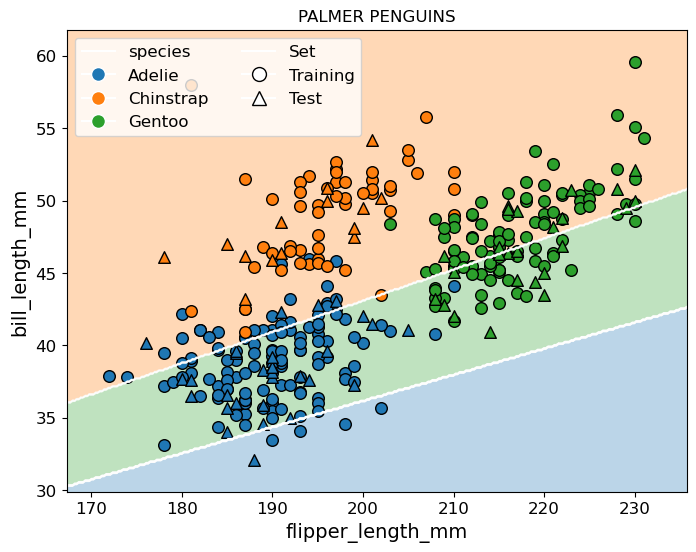

In [32]:
from sklearn.linear_model import Perceptron

perceptron = plot_boundary(Perceptron(random_state=seed), "perceptron_cplot")

# Perceptron: changing the seed

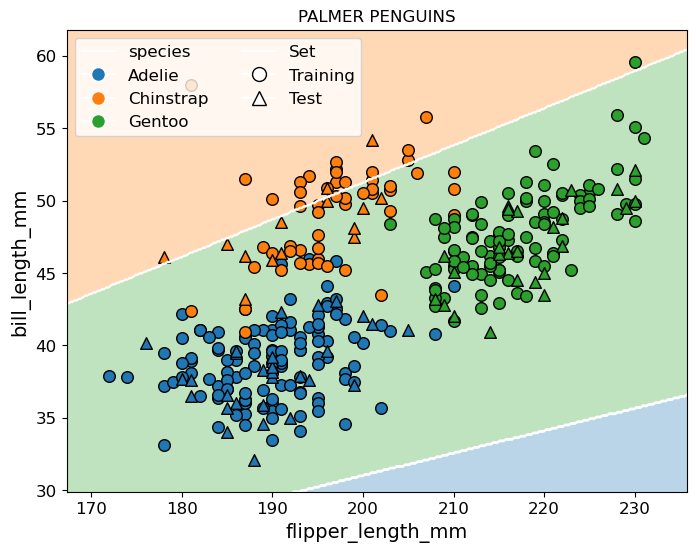

In [33]:
perceptron = plot_boundary(Perceptron(random_state=10), "perceptron_cplot")

# Perceptron: using min-max normalization

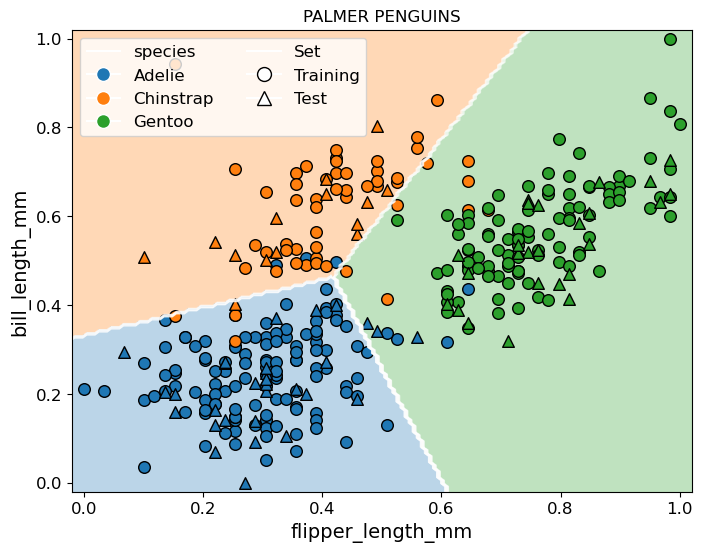

In [34]:
from sklearn.linear_model import Perceptron

perceptron = plot_boundary(Perceptron(random_state=seed), "perceptron_cplot_norm", norm=True)


# Multi-layer perceptron

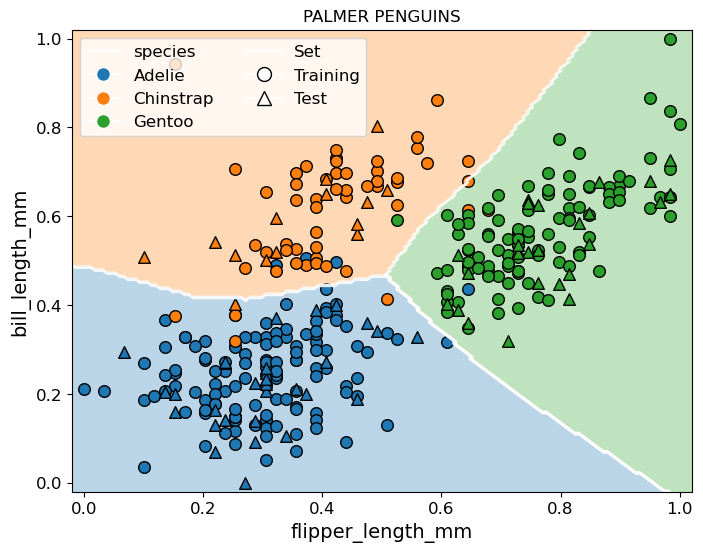

In [35]:
from sklearn.neural_network import MLPClassifier

mlp = plot_boundary(MLPClassifier(hidden_layer_sizes=(10, 20), random_state=seed, max_iter=1000), "mlp_cplot", norm=True)


In [36]:
#| echo: false
model_performance["MLP"] = {
    "model": "MLP",
    "configuration": "hidden_layer_sizes=(10, 20), min-max normalization",
    "CV mean": np.nan,
    "CV std": np.nan,
    "test": mlp.test_score_,
}


# Multi-layer perceptron: no normalization

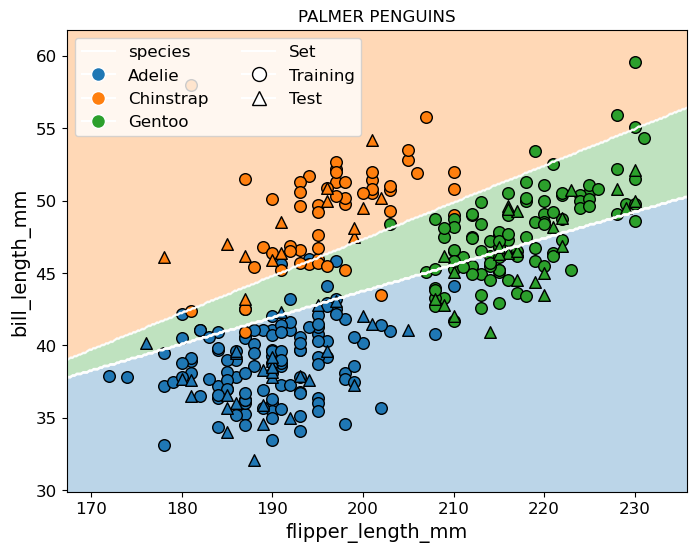

In [37]:
from sklearn.neural_network import MLPClassifier

mlp = plot_boundary(MLPClassifier(hidden_layer_sizes=(10, 20), random_state=seed, max_iter=1000), "mlp_cplot", norm=False)

# Model performance summary


In [38]:
from IPython.display import HTML, display

performance_summary = (
    pd.DataFrame(model_performance.values())
    .loc[:, ["model", "configuration", "CV mean", "CV std", "test"]]
    .sort_values("test", ascending=False)
)

performance_summary

,model,configuration,CV mean,CV std,test
1,Random forest,"max_depth=4, min_samples_leaf=3, min_samples_s...",0.949263,0.014606,1.00000
0,Decision tree,max_depth=2,0.927582,0.022593,0.97619
2,k-NN,"k=10, min-max normalization",0.600907,0.007346,0.97619
3,MLP,"hidden_layer_sizes=(10, 20), min-max normaliza...",NaN,NaN,0.97619


# Exercise

1. Rather than training only on 2 features, use all the numeric ones
1. Train a decision tree
1. What are the most relevant features?
1. Try different configurations of hyperparameters